In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/raw/disaster_prediction_dataset.csv")
data.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0040-BRA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4576,NaN,BRA,...,NaN,NaN,NaN,10000.0,12492.0,80.049596,"[{""adm2_code"":9961,""adm2_name"":""Rio De Janeiro""}]","[{""gid_2"":""BRA.19.68_2"",""migration_date"":""2025...",2018-02-20,2025-12-20
1,2002-0351-USA,No,nat-cli-wil-for,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,USA,...,NaN,NaN,NaN,20000.0,34879.0,57.341840,"[{""adm1_code"":3219,""adm1_name"":""Colorado""}]","[{""gid_1"":""USA.6_1"",""migration_date"":""2025-12-...",2003-07-01,2025-12-20
2,2022-0770-RWA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,RWA,...,NaN,NaN,NaN,NaN,NaN,93.294607,"[{""adm1_code"":21970,""adm1_name"":""Kigali City/U...","[{""gid_1"":""RWA.5_1"",""migration_date"":""2025-12-...",2022-11-25,2025-12-20
3,2024-9796-USA,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,USA,...,NaN,NaN,NaN,5400000.0,5400000.0,100.000000,NaN,"[{""gid_1"":""USA.13_1"",""name_1"":""Idaho""},{""gid_1...",2024-10-29,2025-12-20
4,2000-0620-NGA,No,nat-hyd-flo-fla,Natural,Hydrological,Flood,Flash flood,NaN,NaN,NGA,...,NaN,NaN,NaN,4805.0,8753.0,54.895152,"[{""adm1_code"":2230,""adm1_name"":""Lagos""}]","[{""gid_1"":""NGA.25_1"",""migration_date"":""2025-12...",2005-09-15,2025-12-20


In [3]:
data["Disaster Type"].unique()

<StringArray>
[                      'Flood',                    'Wildfire',
                     'Drought',         'Mass movement (wet)',
           'Volcanic activity',                       'Storm',
                    'Epidemic',                  'Earthquake',
         'Extreme temperature',                 'Infestation',
 'Glacial lake outburst flood',         'Mass movement (dry)',
             'Animal incident',                      'Impact']
Length: 14, dtype: str

In [4]:
selected_types = [
    "Flood",
    "Storm",
    "Epidemic",
    "Earthquake",
    "Extreme temperature"
]
data_5 = data[data["Disaster Type"].isin(selected_types)].copy()
data_5 = data_5.reset_index(drop=True)
data_5.shape

(9205, 47)

In [5]:
data_5["Disaster Type"].value_counts()

Disaster Type
Flood                  4239
Storm                  2815
Epidemic                890
Earthquake              693
Extreme temperature     568
Name: count, dtype: int64

In [6]:
(data_5["Disaster Type"].value_counts(normalize=True)*100).round(2)

Disaster Type
Flood                  46.05
Storm                  30.58
Epidemic                9.67
Earthquake              7.53
Extreme temperature     6.17
Name: proportion, dtype: float64

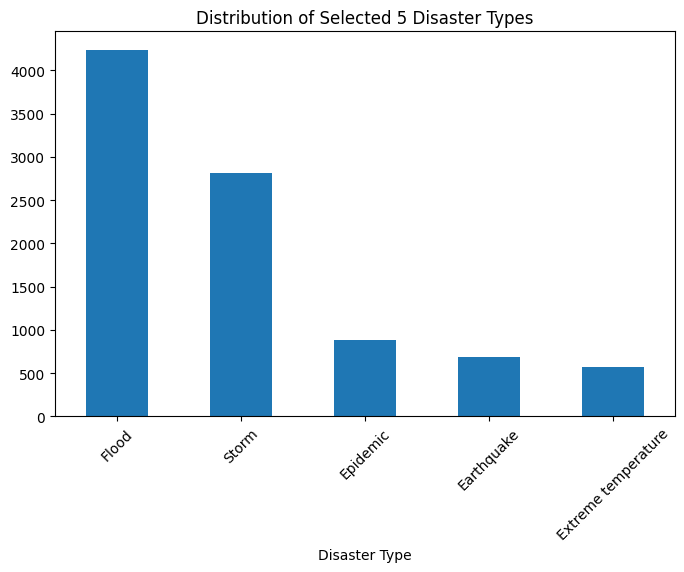

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
data_5["Disaster Type"].value_counts().plot(kind="bar")
plt.title("Distribution of Selected 5 Disaster Types")
plt.xticks(rotation=45)
plt.show()

In [8]:
counts = data_5["Disaster Type"].value_counts()
imbalance_ratio = counts.max() / counts.min()
imbalance_ratio

np.float64(7.463028169014085)

In [21]:
data_5.columns

Index(['Historic', 'Disaster Type', 'Country', 'Subregion', 'Region',
       'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'Start Year', 'Start Month',
       'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths',
       'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected',
       'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI'],
      dtype='str')